In [1]:
import pandas as pd
import jax.numpy as jnp
from jax.experimental.sparse import BCOO
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def convert_COO_file_to_jax(file_name, n_cols=None):
    df = pd.read_csv(file_name)

    # Extract the 'row', 'column', and 'value' columns
    rows = df['row'].values
    cols = df['col'].values
    values = df['data'].values

    # Stack the row and column indices to create the indices array
    indices = jnp.vstack((rows, cols)).T  # Shape: (nnz, 2)

    # Convert the values to a JAX array
    data = jnp.array(values)

    # Determine the shape of the matrix (assuming zero-based indexing)
    if n_cols is None:
        shape = (rows.max()+1, cols.max()+1)
    else:
        shape = (rows.max()+1, n_cols)

    # Create the BCOO matrix
    mat = BCOO((data, indices), shape=shape)
    return mat

In [3]:
def formulate_milp_sparse_inputs(dt_sparse, d_oar1_sparse, d_oar2_sparse, d_oar3_sparse, d_oar4_sparse, Tmax, Tmin, UD_oar1, UD_oar2, UD_oar3, UD_oar4, UV_oar1, UV_oar2, UV_oar3, UV_oar4, M):
    """
    Formulate the mixed-integer linear program (MILP) for the radiation therapy optimization problem,
    using sparse input matrices and outputting the constraint matrix A in JAX's BCOO sparse format.

    Parameters:
    - dt_sparse: scipy.sparse CSR matrix of shape (n_t, m), dose-influence matrix for target
    - d_oar1_sparse: scipy.sparse CSR matrix of shape (n_oar1, m), dose-influence matrix for OAR1
    - d_oar2_sparse: scipy.sparse CSR matrix of shape (n_oar2, m), dose-influence matrix for OAR2
    - d_oar3_sparse: scipy.sparse CSR matrix of shape (n_oar3, m), dose-influence matrix for OAR3
    - d_oar4_sparse: scipy.sparse CSR matrix of shape (n_oar4, m), dose-influence matrix for OAR4
    - Tmax: scalar, upper bound for dose of each voxel in PTV
    - Tmin: scalar, lower bound for dose of each voxel in PTV
    - UD_oar1: scalar, dose-volume constraint for OAR1
    - UD_oar2: scalar, dose-volume constraint for OAR2
    - UD_oar3: scalar, dose-volume constraint for OAR3
    - UD_oar4: scalar, dose-volume constraint for OAR4
    - UV_oar1: scalar, volume fraction constraint for OAR1
    - UV_oar2: scalar, volume fraction constraint for OAR2
    - UV_oar3: scalar, volume fraction constraint for OAR3
    - UV_oar4: scalar, volume fraction constraint for OAR4
    - M: scalar, a large number representing the maximum dose

    Returns:
    - w: numpy array, objective function coefficients
    - A: BCOO sparse matrix, constraint matrix in BCOO format
    - b: numpy array, right-hand side vector
    """

    n_t, m = dt_sparse.shape
    n_oar1, m1 = d_oar1_sparse.shape
    n_oar2, m2 = d_oar2_sparse.shape
    n_oar3, m3 = d_oar3_sparse.shape
    n_oar4, m4 = d_oar4_sparse.shape

    assert m == m1 == m2 == m3 == m4, "Mismatch in number of beamlets"

    # Total number of variables
    n_vars = n_oar1 + n_oar2 + n_oar3 + n_oar4 + m + 2 * n_t  # y_oar1, y_oar2, y_oar3, y_oar4, x_j, sl_i, su_i

    # Total number of constraints
    n_constraints = 2 * n_t + n_oar1 + n_oar2 + n_oar3 + n_oar4 + 4  # Constraints 1-6

    # Initialize objective vector w
    w = np.zeros(n_vars)

    # Indices for variables
    idx_y_oar1 = np.arange(0, n_oar1)
    idx_y_oar2 = np.arange(n_oar1, n_oar1 + n_oar2)
    idx_y_oar3 = np.arange(n_oar1 + n_oar2, n_oar1 + n_oar2 + n_oar3)
    idx_y_oar4 = np.arange(n_oar1 + n_oar2 + n_oar3, n_oar1 + n_oar2 + n_oar3 + n_oar4)
    idx_x = np.arange(n_oar1 + n_oar2 + n_oar3 + n_oar4, n_oar1 + n_oar2 + n_oar3 + n_oar4 + m)
    idx_sl = np.arange(n_oar1 + n_oar2 + n_oar3 + n_oar4 + m, n_oar1 + n_oar2 + n_oar3 + n_oar4 + m + n_t)
    idx_su = np.arange(n_oar1 + n_oar2 + n_oar3 + n_oar4 + m + n_t, n_vars)

    # Set coefficients for sl_i and su_i in objective
    w[idx_sl] = 1
    w[idx_su] = 1

    # Prepare lists to construct sparse matrix
    data = []
    row_indices = []
    col_indices = []

    b = np.zeros(n_constraints)

    # Constraints 1: Upper bound on target dose
    dt_csr = dt_sparse.tocsr()
    for i in range(n_t):
        row = i
        # Get the indices and data for row i
        start = dt_csr.indptr[i]
        end = dt_csr.indptr[i+1]
        cols_i = dt_csr.indices[start:end]
        data_i = dt_csr.data[start:end]

        # Add entries for x_j variables
        data.extend(data_i)
        row_indices.extend([row]*len(cols_i))
        col_indices.extend(idx_x[cols_i])

        # - su_i
        data.append(-1)
        row_indices.append(row)
        col_indices.append(idx_su[i])

        b[row] = Tmax

    # Constraints 2: Lower bound on target dose
    for i in range(n_t):
        row = n_t + i
        start = dt_csr.indptr[i]
        end = dt_csr.indptr[i+1]
        cols_i = dt_csr.indices[start:end]
        data_i = dt_csr.data[start:end]

        data.extend(-data_i)
        row_indices.extend([row]*len(cols_i))
        col_indices.extend(idx_x[cols_i])

        # - sl_i
        data.append(-1)
        row_indices.append(row)
        col_indices.append(idx_sl[i])

        b[row] = -Tmin

    # Constraints 3: OAR1 dose limit
    d_oar1_csr = d_oar1_sparse.tocsr()
    for i in range(n_oar1):
        row = 2 * n_t + i
        start = d_oar1_csr.indptr[i]
        end = d_oar1_csr.indptr[i+1]
        cols_i = d_oar1_csr.indices[start:end]
        data_i = d_oar1_csr.data[start:end]

        data.extend(data_i)
        row_indices.extend([row]*len(cols_i))
        col_indices.extend(idx_x[cols_i])

        # - (M - UD_oar1) * y_oar1[i]
        data.append(-(M - UD_oar1))
        row_indices.append(row)
        col_indices.append(idx_y_oar1[i])

        b[row] = UD_oar1

    # Constraints 4: OAR2 dose limit
    d_oar2_csr = d_oar2_sparse.tocsr()
    for i in range(n_oar2):
        row = 2 * n_t + n_oar1 + i
        start = d_oar2_csr.indptr[i]
        end = d_oar2_csr.indptr[i+1]
        cols_i = d_oar2_csr.indices[start:end]
        data_i = d_oar2_csr.data[start:end]

        data.extend(data_i)
        row_indices.extend([row]*len(cols_i))
        col_indices.extend(idx_x[cols_i])

        # - (M - UD_oar2) * y_oar2[i]
        data.append(-(M - UD_oar2))
        row_indices.append(row)
        col_indices.append(idx_y_oar2[i])

        b[row] = UD_oar2
        
    # Constraints 5: OAR3 dose limit
    d_oar3_csr = d_oar3_sparse.tocsr()
    for i in range(n_oar3):
        row = 2 * n_t + n_oar1 + n_oar2 + i
        start = d_oar3_csr.indptr[i]
        end = d_oar3_csr.indptr[i+1]
        cols_i = d_oar3_csr.indices[start:end]
        data_i = d_oar3_csr.data[start:end]

        data.extend(data_i)
        row_indices.extend([row]*len(cols_i))
        col_indices.extend(idx_x[cols_i])

        # - (M - UD_oar3) * y_oar3[i]
        data.append(-(M - UD_oar3))
        row_indices.append(row)
        col_indices.append(idx_y_oar3[i])

        b[row] = UD_oar3
    
    # Constraints 6: OAR4 dose limit
    d_oar4_csr = d_oar4_sparse.tocsr()
    for i in range(n_oar4):
        row = 2 * n_t + n_oar1 + n_oar2 + n_oar3 + i
        start = d_oar4_csr.indptr[i]
        end = d_oar4_csr.indptr[i+1]
        cols_i = d_oar4_csr.indices[start:end]
        data_i = d_oar4_csr.data[start:end]

        data.extend(data_i)
        row_indices.extend([row]*len(cols_i))
        col_indices.extend(idx_x[cols_i])

        # - (M - UD_oar4) * y_oar4[i]
        data.append(-(M - UD_oar4))
        row_indices.append(row)
        col_indices.append(idx_y_oar4[i])

        b[row] = UD_oar4



    # Constraint 7: OAR1 voxel limit
    row = 2 * n_t + n_oar1 + n_oar2 + n_oar3 + n_oar4
    indices = idx_y_oar1
    values = np.ones(len(idx_y_oar1))

    data.extend(values)
    row_indices.extend([row]*len(indices))
    col_indices.extend(indices)

    b[row] = UV_oar1 * n_oar1

    # Constraint 8: OAR2 voxel limit
    row = 2 * n_t + n_oar1 + n_oar2 + n_oar3 + n_oar4 + 1
    indices = idx_y_oar2
    values = np.ones(len(idx_y_oar2))

    data.extend(values)
    row_indices.extend([row]*len(indices))
    col_indices.extend(indices)

    b[row] = UV_oar2 * n_oar2

    # Constraint 9: OAR3 voxel limit
    row = 2 * n_t + n_oar1 + n_oar2 + n_oar3 + n_oar4 + 2
    indices = idx_y_oar3
    values = np.ones(len(idx_y_oar3))

    data.extend(values)
    row_indices.extend([row]*len(indices))
    col_indices.extend(indices)

    b[row] = UV_oar3 * n_oar3

    # Constraint 10: OAR4 voxel limit
    row = 2 * n_t + n_oar1 + n_oar2 + n_oar3 + n_oar4 + 3
    indices = idx_y_oar4
    values = np.ones(len(idx_y_oar4))

    data.extend(values)
    row_indices.extend([row]*len(indices))
    col_indices.extend(indices)

    b[row] = UV_oar4 * n_oar4

    # Convert lists to JAX arrays
    data = jnp.array(data)
    row_indices = jnp.array(row_indices)
    col_indices = jnp.array(col_indices)
    shape = (n_constraints, n_vars)

    # Stack row and column indices to form the coordinates
    coords = jnp.stack((row_indices, col_indices), axis=-1)

    # Create BCOO sparse matrix
    A_sparse = BCOO((data, coords), shape=shape)

    return w, A_sparse, b

In [50]:
rectum_mat = convert_COO_file_to_jax('Rectum.csv')
bladder_mat = convert_COO_file_to_jax('Bladder.csv')
bone_Lt_mat = convert_COO_file_to_jax('Bone_Lt.csv')
bone_Rt_mat = convert_COO_file_to_jax('Bone_Rt.csv')
prostate_mat = convert_COO_file_to_jax('Prostate.csv')
n_oar1 = rectum_mat.shape[0]
n_oar2 = bladder_mat.shape[0]
n_oar3 = bone_Lt_mat.shape[0]
n_oar4 = bone_Rt_mat.shape[0]
m = prostate_mat.shape[1]
n_t = prostate_mat.shape[0]

UV_oar1 = 0.2
UV_oar2 = 0.35
UV_oar3 = 0.03
UV_oar4 = 0.03

tmin = 171
tmax = 180
UD_oar1 = 170
UD_oar2 = 171
UD_oar3 = 122
UD_oar4 = 122
M = 200
Vt = prostate_mat.shape[0]
B = prostate_mat.shape[1]
r = 1
ub = 200

In [5]:
to_scipy = lambda x: sp.sparse.coo_array((x.data, x.indices.transpose()), shape=x.shape)
w, A, b = formulate_milp_sparse_inputs(to_scipy(prostate_mat), to_scipy(rectum_mat), to_scipy(bladder_mat), to_scipy(bone_Lt_mat), to_scipy(bone_Rt_mat), tmax, tmin, UD_oar1, UD_oar2, UD_oar3, UD_oar4,  UV_oar1, UV_oar2,UV_oar3, UV_oar4, M)

In [6]:
cs=to_scipy(prostate_mat)
print("Min nonzero in prostate_mat:", cs.data.min())
cs=to_scipy(bladder_mat)
print("Min nonzero in bladder_mat:", cs.data.min())
cs=to_scipy(rectum_mat)
print("Min nonzero in rectum_mat:",  cs.data.min())
cs=to_scipy(bone_Lt_mat)
print("Min nonzero in bone_Lt_mat:", cs.data.min())
cs=to_scipy(bone_Rt_mat)
print("Min nonzero in bone_Rt_mat:", cs.data.min())


Min nonzero in prostate_mat: 2.06e-08
Min nonzero in bladder_mat: 3.16e-10
Min nonzero in rectum_mat: 9.04e-11
Min nonzero in bone_Lt_mat: 1.3e-10
Min nonzero in bone_Rt_mat: 3.11e-11


In [51]:
n_bin = n_oar1 + n_oar2 + n_oar3 + n_oar4
lb = np.zeros(w.shape[0])
ub = np.concatenate((np.zeros(n_bin), np.full(m, ub), np.full(2 * n_t, 1)))
Q = sp.sparse.csc_matrix((w.shape[0], w.shape[0]))
A_coo = sp.sparse.coo_matrix((np.array(A.data), (np.array(A.indices[:, 0]), np.array(A.indices[:, 1]))), shape=A.shape)
A_csc = A_coo.tocsc()
C = sp.sparse.csc_matrix((0, w.shape[0]))
d = np.zeros(0)

In [ ]:
from phisolve.utils.file_utils import save_miqp

save_miqp("imrt_instance.npz", Q, w, A_csc, b, C, d, lb, ub, n_bin, None, "min")

In [7]:
#DVhcurve plotter

def plot_DVh_curve(dt_mat, oar1_mat,  oar2_mat,oar3_mat,oar4_mat,structure_names,optimal_intensity, max_dose=200):

    """
    Plots the DVh curve for a given structure.
    """     
    dose={structure_names[0]: dt_mat @ optimal_intensity,
          structure_names[1]: oar1_mat @ optimal_intensity,
          structure_names[2]: oar2_mat @ optimal_intensity,
          structure_names[3]: oar3_mat @ optimal_intensity,
          structure_names[4]: oar4_mat @ optimal_intensity}

    xax = np.linspace(0, max_dose, max_dose)

    plt.figure()
    ax = plt.gca()

    for j in range(len(structure_names)):
        dvh_array = np.zeros((max_dose,1))
        for i in range(max_dose):
            dvh_array[i] = ((dose[structure_names[j]] >= i).sum() / len(dose[structure_names[j]])) * 100
        plt.plot(xax, dvh_array, label=structure_names[j])
    
    plt.legend()
    ax.minorticks_on()
    ax.grid(which='minor', linestyle=':', linewidth='0.5')
    ax.grid(which='major', linestyle='-', linewidth='1')



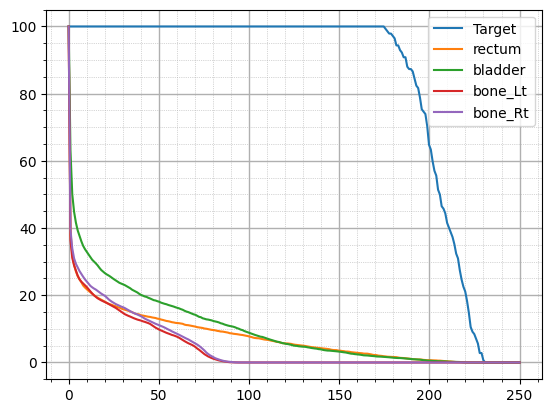

In [8]:
unoptimized_weights= np.ones(prostate_mat.shape[1])
plot_DVh_curve(to_scipy(prostate_mat), to_scipy(rectum_mat), to_scipy(bladder_mat), to_scipy(bone_Lt_mat), to_scipy(bone_Rt_mat),['Target', 'rectum', 'bladder', 'bone_Lt', 'bone_Rt'],unoptimized_weights,250)